# MetaVoteNet-ML: A Pure Machine Learning Stacked Ensemble System

## Overview

MetaVoteNet-ML is a multi-model ensemble framework built entirely using classical Machine Learning algorithms.

Instead of relying on a single algorithm, this system trains multiple diverse ML models:

- Random Forest (Bagging-based Ensemble)
- XGBoost (Boosting-based Ensemble)
- Gradient Boosting
- Logistic Regression

Each model captures different structural patterns in the dataset.

## Core Innovation

Rather than using simple majority voting, MetaVoteNet-ML introduces a Meta-Learning Layer that:

- Collects prediction probabilities from base models
- Learns which model performs best under different conditions
- Dynamically assigns trust
- Produces a final intelligent prediction

This technique is known as **Stacked Ensemble Learning**.

## Architecture Flow

Input Data  
↓  
Base ML Models (RF, XGBoost, GB, LR)  
↓  
Meta-Model (Learns Reliability Patterns)  
↓  
Final Intelligent Prediction  

## Goal

To demonstrate that intelligent stacking of classical machine learning models can:

- Improve predictive performance
- Increase robustness
- Reduce bias
- Enhance decision reliability

This project focuses entirely on advanced Machine Learning ensemble techniques.

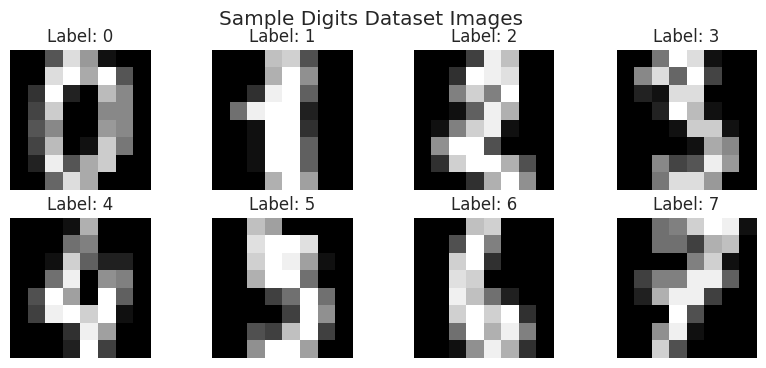

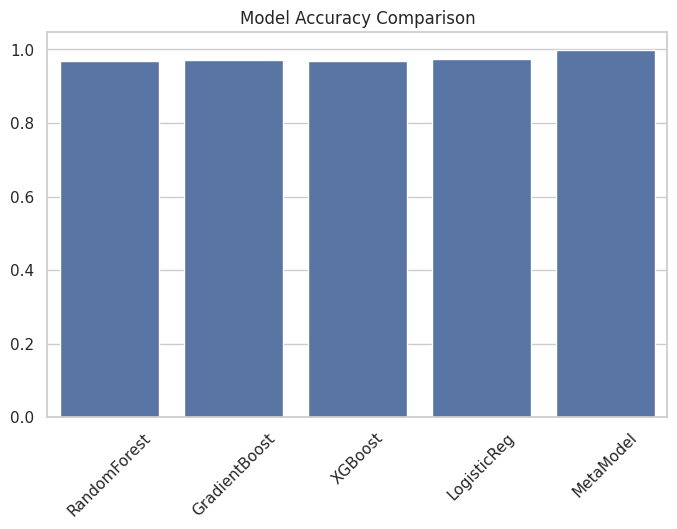

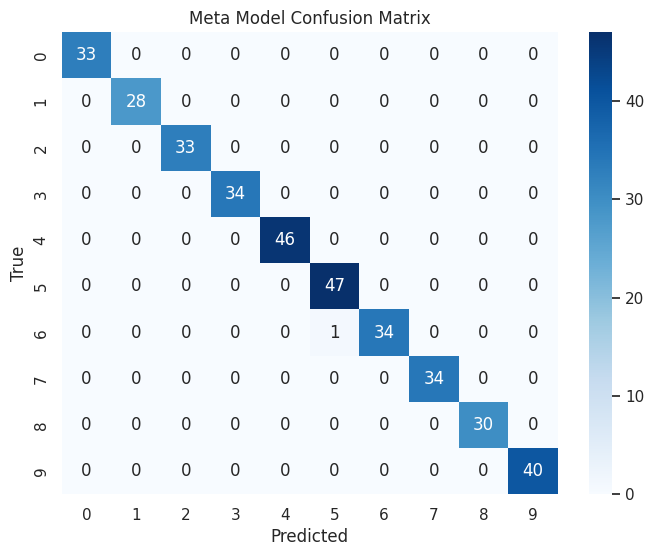

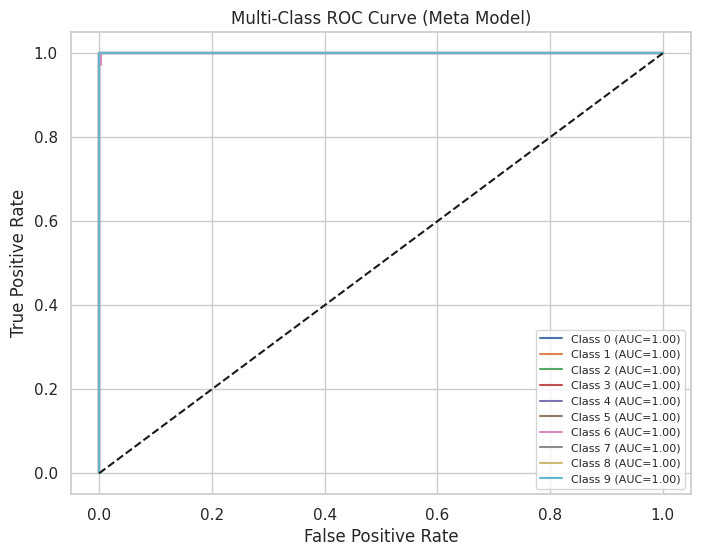

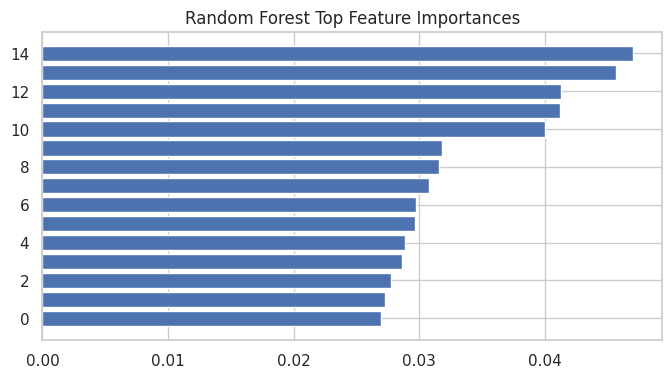

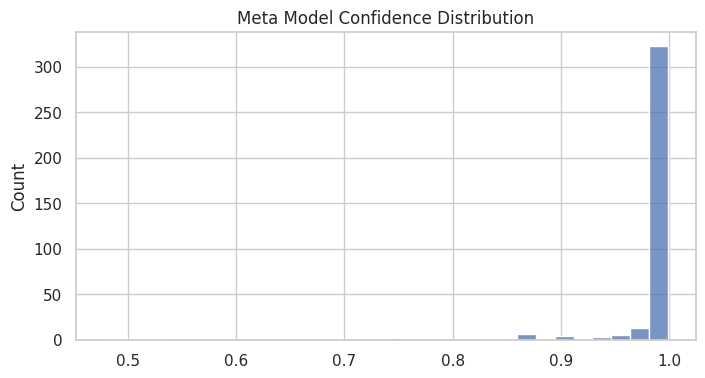

Random Forest Accuracy: 0.9694444444444444
Gradient Boost Accuracy: 0.9722222222222222
XGBoost Accuracy: 0.9694444444444444
Logistic Regression Accuracy: 0.975
Meta Model Accuracy: 0.9972222222222222

Classification Report (Meta Model):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      1.00      0.99        47
           6       1.00      0.97      0.99        35
           7       1.00      1.00      1.00        34
           8       1.00      1.00      1.00        30
           9       1.00      1.00      1.00        40

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360


Me

In [2]:
# ==========================================================
# MetaVoteNet-ML: Pure Machine Learning Stacked Ensemble
# RF + XGBoost + GradientBoosting + LogisticRegression
# With Advanced Visualizations
# ==========================================================

!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
import xgboost as xgb

sns.set(style="whitegrid")

# ==========================================================
# 1. Load Dataset (Digits Dataset)
# ==========================================================

digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ==========================================================
# 2. Visualize Sample Images
# ==========================================================

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {digits.target[i]}")
    plt.axis("off")
plt.suptitle("Sample Digits Dataset Images")
plt.show()

# ==========================================================
# 3. Base Model 1 - Random Forest
# ==========================================================

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

# ==========================================================
# 4. Base Model 2 - Gradient Boosting
# ==========================================================

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_probs = gb.predict_proba(X_test)
gb_preds = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_preds)

# ==========================================================
# 5. Base Model 3 - XGBoost
# ==========================================================

xgb_model = xgb.XGBClassifier(eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

xgb_probs = xgb_model.predict_proba(X_test)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

# ==========================================================
# 6. Base Model 4 - Logistic Regression
# ==========================================================

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

lr_probs = lr.predict_proba(X_test)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

# ==========================================================
# 7. Stacking Meta Model
# ==========================================================

meta_X = np.hstack([rf_probs, gb_probs, xgb_probs, lr_probs])
meta_y = y_test

scaler = StandardScaler()
meta_X = scaler.fit_transform(meta_X)

meta_model = LogisticRegression(max_iter=2000)
meta_model.fit(meta_X, meta_y)

final_preds = meta_model.predict(meta_X)
meta_acc = accuracy_score(meta_y, final_preds)

# ==========================================================
# 8. Accuracy Comparison
# ==========================================================

models = ["RandomForest", "GradientBoost", "XGBoost", "LogisticReg", "MetaModel"]
accuracies = [rf_acc, gb_acc, xgb_acc, lr_acc, meta_acc]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

# ==========================================================
# 9. Confusion Matrix (Meta Model)
# ==========================================================

cm = confusion_matrix(meta_y, final_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Meta Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ==========================================================
# 10. ROC Curve (Meta Model)
# ==========================================================

y_bin = label_binarize(meta_y, classes=range(10))
meta_probs = meta_model.predict_proba(meta_X)

plt.figure(figsize=(8,6))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_bin[:, i], meta_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("Multi-Class ROC Curve (Meta Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.show()

# ==========================================================
# 11. Feature Importance (Random Forest)
# ==========================================================

plt.figure(figsize=(8,4))
indices = np.argsort(rf.feature_importances_)[-15:]
plt.barh(range(len(indices)), rf.feature_importances_[indices])
plt.title("Random Forest Top Feature Importances")
plt.show()

# ==========================================================
# 12. Confidence Distribution
# ==========================================================

confidence = np.max(meta_probs, axis=1)

plt.figure(figsize=(8,4))
sns.histplot(confidence, bins=30)
plt.title("Meta Model Confidence Distribution")
plt.show()

# ==========================================================
# Final Results
# ==========================================================

print("Random Forest Accuracy:", rf_acc)
print("Gradient Boost Accuracy:", gb_acc)
print("XGBoost Accuracy:", xgb_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("Meta Model Accuracy:", meta_acc)

print("\nClassification Report (Meta Model):\n")
print(classification_report(meta_y, final_preds))

print("\nMetaVoteNet-ML Completed Successfully ")